In [32]:
import jVMC_exp
from jVMC_exp.operator.discrete import Number, Creation, Annihilation
from jVMC_exp.vqs import NQS

import jax.numpy as jnp
import flax.linen as nn
import numpy as np
import matplotlib.pyplot as plt

from openfermion.ops import FermionOperator as fop
from openfermion.linalg import get_sparse_operator

In [33]:
# custon tarbget wave function
# specific to openfermion compatibility
class Target(nn.Module):
  """
  Target wave function, returns a vector with the same dimension as the Hilbert space

    Initialization arguments:
        * ``L``: System size
        * ``d``: local Hilbert space dimension
        * ``delta``: small number to avoid log(0)

  """
  L: int
  d: float = 2.00
  delta: float = 1e-15

  @nn.compact
  def __call__(self, s):
    kernel = self.param('kernel', nn.initializers.constant(1), (int(self.d**self.L)))
    # return amplitude for state s
    # NOTE that the state is reversed to account for different bit conventions used in openfermion
    idx = ((self.d**jnp.arange(self.L)).dot(s[::-1])).astype(int) 

    return jnp.log(abs(kernel[idx] + self.delta)) + 1.j * jnp.angle(kernel[idx]) 

## Fermionic operators

Fermionic operators have to satisfy the following anticommutation relation
$$
\lbrace \hat{c}^\dagger_i, \hat{c}_j\rbrace  = \delta_{ij} \; ,
$$
where $i,j$ are so-called *flavours*. As is done in 'openfermoin' we do not allow for a spin quantum number. In other words, all our fermionic operators can only carry a single flavour. For higher flavour indeces one has combine several distinct fermionis.

The key to realizing fermions is the Jordan-Wigner factor. Every fermionic state is constructed using a filling order, then we have to count how many craetion operatros a given operator has to commute thorugh to arrive at his filling order position.
We can achieve this as follows.
$$
\hat{c}^\dagger\vert 1, 0 \rangle = (-1)^\Omega \vert 1,1\rangle
$$
with 
$$
\Omega = \sum^{j-1}_{i=0} s_i \; .
$$
In the following we construct the repulsive Hubbard Model on a chain as an example and compare it to openfermion
$$
H =  U \sum^N_{i=1} \hat{n}_{\uparrow i}\hat{n}_{\downarrow i}  + t \sum^{N-1}_{i=1}  \hat{c}^\dagger_{\sigma i} \hat{c}_{\sigma i+1} + h.c.  \;.
$$ 

In [34]:
# jVMC_exp hamiltonian
t = - 1.0                       # hopping
mu = -2.0                       # chemical potential
U = 4.0                         # interaction
L = 4                           # number of sites
flavour = 2                     # number of flavours
sample_shape = flavour * L      # number of spins times sites

# initalize the Hamitonian
hamiltonian = 0
# impurity definitions
site_up = 0
site_down = L
# loop over the 1d lattice
for i_up, i_down in zip(range(L), range(L, 2 * L)):
    # interaction
    hamiltonian += U * Number(i_up) * Number(i_down)
    # chemical potential
    hamiltonian += mu * (Number(i_up) + Number(i_down))

    if i_up == L - 1:
        continue
    
    # up chain hopping
    hamiltonian += t * (Creation(i_up) * Annihilation(i_up + 1) + Creation(i_up + 1) * Annihilation(i_up))
    # down chain hopping
    hamiltonian += t * (Creation(i_down) * Annihilation(i_down + 1) + Creation(i_down + 1) * Annihilation(i_down))

In [ ]:
# openfermion

H = 0.0 * fop()
# loop over the 1d lattice
for i_up, i_down in zip(range(L), range(L, 2 * L)):
    # interaction
    H += fop(((i_up, 1), (i_up, 0), (i_down, 1), (i_down, 0)), U) 
    # chemical potential
    H += fop(((i_up, 1), (i_up, 0)), mu) + fop(((i_down, 1),(i_down, 0)), mu)

    if i_up == L - 1:
        continue
    
    # up chain
    H += (fop(((i_up, 1), (i_up + 1,0)), t) + fop(((i_up + 1, 1),(i_up, 0)), t))
    # down chain
    H += (fop(((i_down, 1),(i_down + 1,0)), t) + fop(((i_down + 1, 1),(i_down, 0)), t))

In [36]:
# Check that the two hamiltonians are consistent

ham = get_sparse_operator(H)
a, b = np.linalg.eigh(ham.toarray())

chi_model = Target(L=sample_shape, d=2)
chi = NQS(chi_model, sampleShape=sample_shape, batchSize=2**sample_shape)
chi.parameters = b[:, 0] + 1e-14
chiSampler = jVMC_exp.sampler.ExactSampler(chi)

e_jvmc = chiSampler(hamiltonian).mean.real.item()
e_openfermion = a[0]

print(f"Are the same? ", jnp.allclose(e_jvmc, e_openfermion))

Are the same?  True


### Finding the ground state brute force

In [47]:
# Set up variational wave function
all_states = Target(L=sample_shape, d=2)
psi = NQS(all_states, sampleShape=sample_shape, batchSize=2**sample_shape)

# Set up exact sampler
sampler = jVMC_exp.sampler.ExactSampler(psi)

# Set up optimization
stepper = jVMC_exp.stepper.Euler(5e-1)
loss_function = jVMC_exp.objective_function.Observable(hamiltonian)
opt = jVMC_exp.optimizer.SR(sampler, psi, diagonalScale=10)

In [48]:
out = opt.ground_state_search(700, loss_function, stepper)

100%|██████████| 700/700 [00:32<00:00, 21.43it/s, E=-9.9531e+00+0.0000e+00j ± 8.1103e-09 (Var = 5.3621e-16)]

Recorded timings:
    • sampling: 1.039549s
    • compute objective function and gradient: 9.696830s
    • solve: 19.281528s


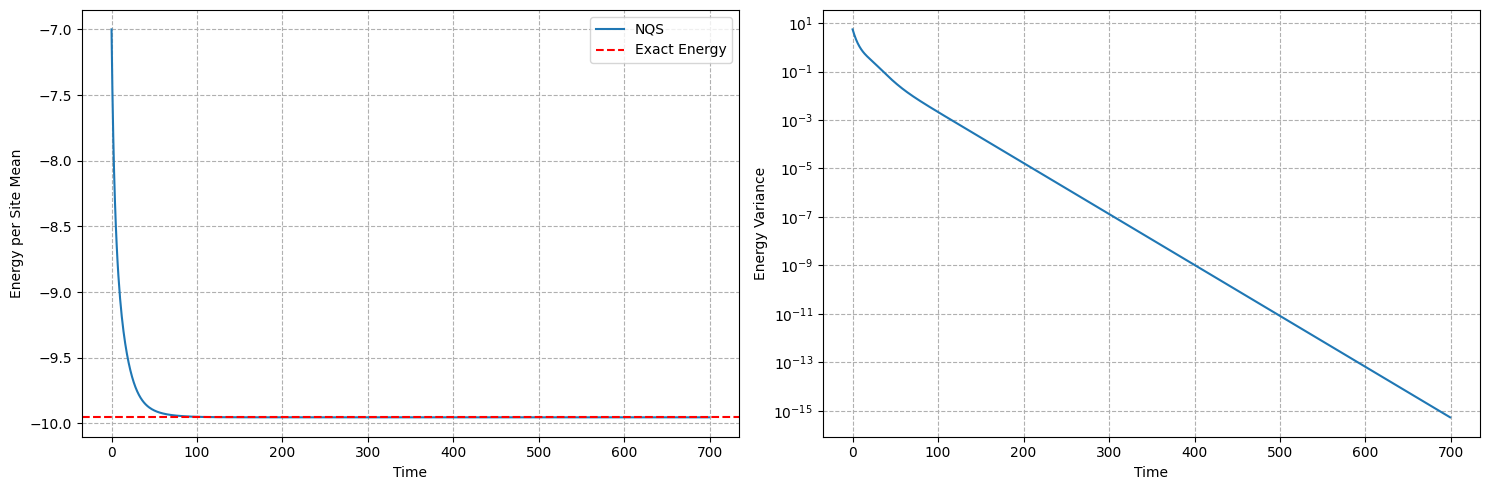

In [49]:
times = out["times"]
energy_mean = np.array(out["energy"]["mean"]).real
energy_var = np.array(out["energy"]["variance"])

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(times, energy_mean, label="NQS")
plt.axhline(a[0], label="Exact Energy", ls="--", color="red")
plt.ylabel("Energy per Site Mean")
plt.xlabel("Time")
plt.legend()
plt.grid(ls="--")

plt.subplot(1, 2, 2)
plt.plot(times, energy_var)
plt.yscale("log")
plt.ylabel("Energy Variance")
plt.xlabel("Time")
plt.grid(ls="--")

plt.tight_layout()

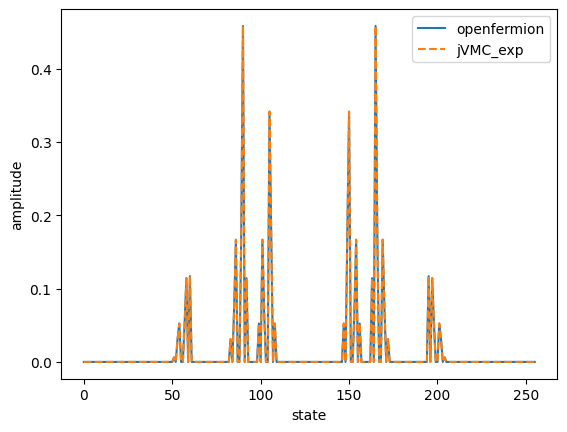

In [52]:
var_wf = np.real(np.exp(sampler.logPsi))
# normalizing the wave function
var_wf /= var_wf.dot(var_wf)**0.5

plt.plot(np.exp(chi(sampler.samples)).real, label='openfermion', zorder=1)
plt.plot(var_wf, label='jVMC_exp', ls="--", zorder=2)
plt.xlabel('state')
plt.ylabel('amplitude')
plt.legend()